#DATA MINING AND NEURAL NETWORKS    
##Assignment 2.2.1 - Classification

Prof. Dr. Ir. Johan A. K. Suykens     

In this file, we work on the classification using Multilayer Perceptron (MLP).

Specifically, we will conduct prediction on Ionosphere and Diabetes datasets.
The method is implemented with a ``python`` package named ``scikit-learn``.


In [ ]:
# Please first load your google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Please go to the folder with all assignment files
# Please change the following path to your own path
!cd /content/drive/MyDrive/

In [ ]:
!ls

drive  sample_data


In [2]:
!pip install openml

# Classification with MLP

In [76]:
import numpy as np
import openml
import math

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

## Ionosphere dataset
We first load the dataset, you can check the index of datasets from [here](https://www.openml.org/search?type=data&sort=runs&status=active).

In [77]:
# Load the dataset
dataset = openml.datasets.get_dataset(59)
# Turn data into numpy array
X, _, _, _ = dataset.get_data(dataset_format="array")
# Check the data size and dimension
print(X.shape)
# Separate input and targets
y = X[:,-1]
X = X[:,:-1]

# Partition dataset into training, validation and test sets
X_sub, X_test, y_sub, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_sub, y_sub, test_size=0.2)

(351, 35)


c:\Users\afs\anaconda3\Lib\site-packages\openml\datasets\functions.py:438: FutureWarning: Starting from Version 0.15 `download_data`, `download_qualities`, and `download_features_meta_data` will all be ``False`` instead of ``True`` by default to enable lazy loading. To disable this message until version 0.15 explicitly set `download_data`, `download_qualities`, and `download_features_meta_data` to a bool while calling `get_dataset`.
  warnings.warn(
C:\Users\afs\AppData\Local\Temp\ipykernel_10068\1961910716.py:4: FutureWarning: Support for `dataset_format='array'` will be removed in 0.15,start using `dataset_format='dataframe' to ensure your code will continue to work. You can use the dataframe's `to_numpy` function to continue using numpy arrays.
  X, _, _, _ = dataset.get_data(dataset_format="array")


You can visualize the potential relationships or correlations amongst the different data attributes by leveraging a pair-wise correlation matrix and depict it as a heatmap.

c:\Users\afs\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\afs\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


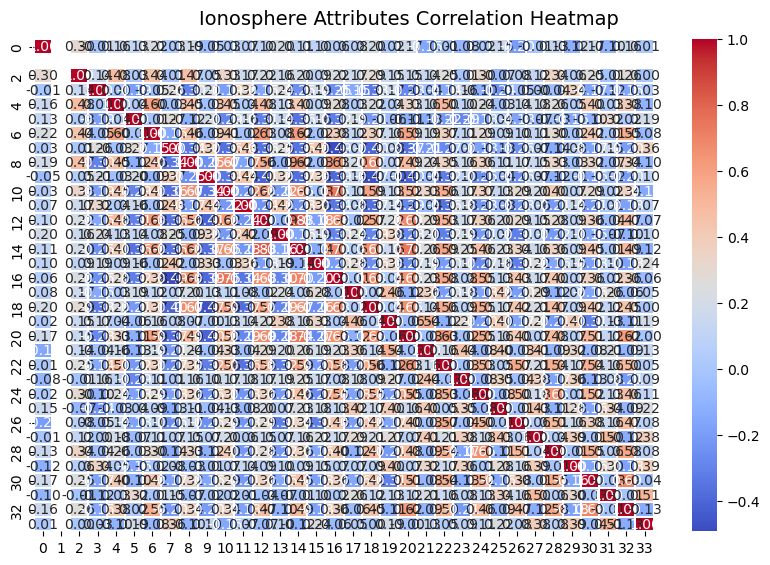

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

f, ax = plt.subplots(figsize=(10, 6))
corr = np.corrcoef(X.transpose())
hm = sns.heatmap(corr, annot=True, ax=ax, cmap="coolwarm",fmt='.2f',
                 linewidths=.05)
f.subplots_adjust(top=0.93)
t= f.suptitle('Ionosphere Attributes Correlation Heatmap', fontsize=14)

In [120]:
corr.shape

(34, 34)

Build a MLP and train it on the training set.
Note that we can use ``MLPClassifier`` from ``sklearn`` to build and train the network.

A detailed instruction of the ``MLPClassifier`` function can be found in [this instruction page](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html).

You can tune on the number of layers, number of neurons in each layer, max_iter, optimizer, etc., to obtain better performance.
Please tune the hyper-parameters based on the accuracy on the validation set.

Once you decide your best hyper-parameters setting, you can evaluate the model on the test set.

In [83]:
# Build the MLP
# You can build multiple layers simpley by adding number of neurons in each layer in hidden_layer_sizes
clf = MLPClassifier(hidden_layer_sizes=(50,50,50,50), activation='relu', solver='sgd', max_iter=5000, batch_size=64) # solver{‘lbfgs’, ‘sgd’, ‘adam’}, default=’adam’

# Train the MLP on the training set
clf.fit(X_train, y_train)

# Evaluatte the MLP on the validation set
y_val_pred = clf.predict(X_val)
acc_val = accuracy_score(y_val, y_val_pred)

print("Acc on the validation set is {:.3f}".format(acc_val))

Acc on the validation set is 0.929


In [82]:
# Evaluatte the MLP on the validation set
y_test_pred = clf.predict(X_test)
acc_test = accuracy_score(y_test, y_test_pred)

print("Acc on the test set is {:.3f}".format(acc_test))

Acc on the test set is 0.901


<Axes: >

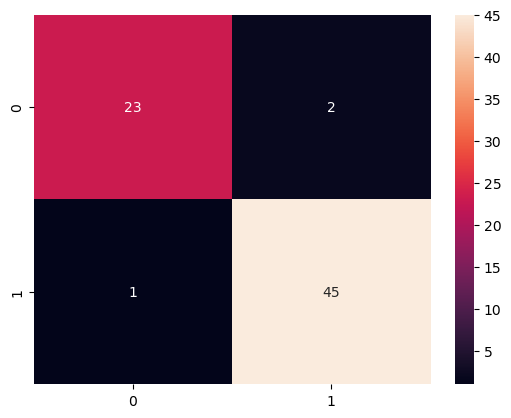

In [207]:
# You can also plot the confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True)

## Diabetes dataset
We first load the dataset, you can check the index of datasets from [here](https://www.openml.org/search?type=data&sort=runs&status=active).

In [4]:
# Load the dataset
dataset = openml.datasets.get_dataset(42608)
# Turn data into numpy array
X, _, _, _ = dataset.get_data(dataset_format="array")
# Check the data size and dimension
print(X.shape)
# Separate input and targets
y = X[:,-1]
X = X[:,:-1]

# Partition dataset into training, validation and test sets
X_sub, X_test, y_sub, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_sub, y_sub, test_size=0.2)

(768, 9)


c:\Users\afs\anaconda3\Lib\site-packages\openml\datasets\functions.py:438: FutureWarning: Starting from Version 0.15 `download_data`, `download_qualities`, and `download_features_meta_data` will all be ``False`` instead of ``True`` by default to enable lazy loading. To disable this message until version 0.15 explicitly set `download_data`, `download_qualities`, and `download_features_meta_data` to a bool while calling `get_dataset`.
  warnings.warn(
C:\Users\afs\AppData\Local\Temp\ipykernel_10068\1142496366.py:4: FutureWarning: Support for `dataset_format='array'` will be removed in 0.15,start using `dataset_format='dataframe' to ensure your code will continue to work. You can use the dataframe's `to_numpy` function to continue using numpy arrays.
  X, _, _, _ = dataset.get_data(dataset_format="array")


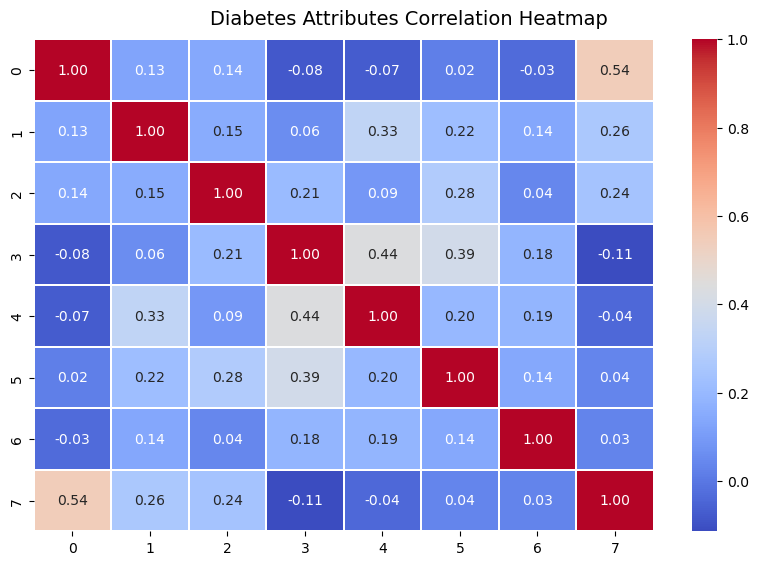

In [5]:
# Visualize the correlation matrix of the dataset
import seaborn as sns
import matplotlib.pyplot as plt

f, ax = plt.subplots(figsize=(10, 6))
corr = np.corrcoef(X.transpose())
hm = sns.heatmap(corr, annot=True, ax=ax, cmap="coolwarm",fmt='.2f',
                 linewidths=.05)
f.subplots_adjust(top=0.93)
t= f.suptitle('Diabetes Attributes Correlation Heatmap', fontsize=14)

In [75]:
# Build the MLP
# You can build multiple layers simpley by adding number of neurons in each layer in hidden_layer_sizes
clf = MLPClassifier(hidden_layer_sizes=(100,100,100,50), activation='adam', solver='sgd', max_iter=10000, alpha=0.1, batch_size=128) # solver{‘lbfgs’, ‘sgd’, ‘adam’}, default=’adam’

# Train the MLP on the training set
clf.fit(X_train, y_train)

# Evaluatte the MLP on the validation set
y_val_pred = clf.predict(X_val)
acc_val = accuracy_score(y_val, y_val_pred)

print("Acc on the validation set is {:.3f}".format(acc_val))

Acc on the validation set is 0.683


In [67]:
# Evaluatte the MLP on the validation set
y_test_pred = clf.predict(X_test)
acc_test = accuracy_score(y_test, y_test_pred)

print("Acc on the test set is {:.3f}".format(acc_test))

Acc on the test set is 0.643


<Axes: >

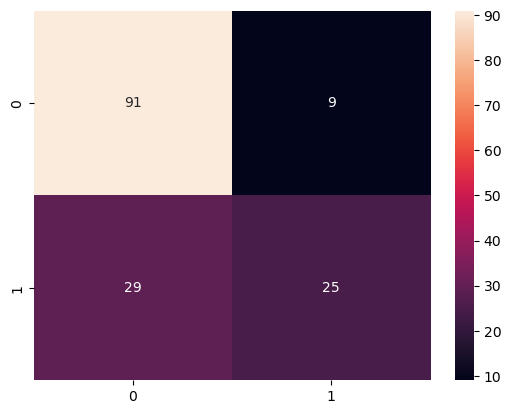

In [56]:
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True)